恐竜の健康診断の回帰分析

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
!pip install japanize-matplotlib
import japanize_matplotlib

恐竜の健康診断

In [3]:
# 恐竜のDataFrame
name = ["アルゼンチノサウルス", "パタゴテイタン", "トｳリアサウルス",
         "スーパサウルス", "プラキオサウルス", "サウロポセイドン",
         "パラサウロフス", "エバンテリアス"]

col = ["なまえ", "身長m", "体重kg"]

body = [[34, 90000], [38, 73000], [35, 45000], [30, 40000],
        [22, 30000], [30, 60000], [10, 40000], [12, 2000]]


In [9]:
dinosaur = []
for i in range(len(name)):
  dinosaur.append([name[i]] + body[i])

# DataFrame を作成
df = pd.DataFrame(data=dinosaur, columns=col)

display(df)

,なまえ,身長m,体重kg
0,アルゼンチノサウルス,34,90000
1,パタゴテイタン,38,73000
2,トｳリアサウルス,35,45000
3,スーパサウルス,30,40000
4,プラキオサウルス,22,30000
5,サウロポセイドン,30,60000
6,パラサウロフス,10,40000
7,エバンテリアス,12,2000


In [10]:
# "アフリカゾウ"  4m   7000kg

df.loc[len(df)] = ["アフリカゾウ", 4, 7000]

df = df.set_index("なまえ")
display(df)


,身長m,体重kg
なまえ,,
アルゼンチノサウルス,34,90000
パタゴテイタン,38,73000
トｳリアサウルス,35,45000
スーパサウルス,30,40000
プラキオサウルス,22,30000
サウロポセイドン,30,60000
パラサウロフス,10,40000
エバンテリアス,12,2000
アフリカゾウ,4,7000


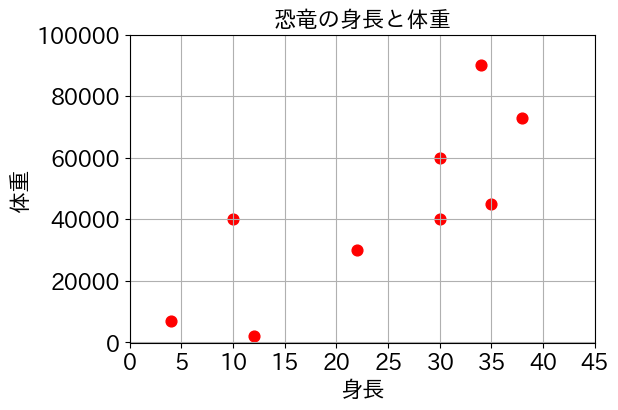

In [17]:
# グラフ　散布図をつくる
plt.figure(figsize=[6, 4])
plt.scatter(df["身長m"], df["体重kg"], s=60, c="red", )
plt.title("恐竜の身長と体重", fontsize=16)
plt.grid(True)
plt.xlabel("身長", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel("体重", fontsize=16)
plt.xlim(0, 45)
plt.ylim(-100, 100000)
plt.show()

単回帰分析を開始する

In [18]:
# 回帰分析に必要なモジュールのインポート

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from matplotlib import pyplot as plt

In [25]:
# 回帰モデルの作成と学習

# 線形回帰モデルを読み込む
model = LinearRegression()

X = df[["身長m"]]
y = df["体重kg"]
model.fit(X, y)

# 予測値の計算
y_pred = model.predict(X)

# R^2スコアの計算
r2 = r2_score(y, y_pred)
print(f'R^2スコア: {r2:.4f}')

# RMSE
rmse = root_mean_squared_error(y, y_pred)
print("RMSE={:.4f}".format(rmse))

# モデルの係数と切片の表示
print(f'係数 (slope): {model.coef_[0]:.4f}')
print(f'切片 (intercept): {model.intercept_:.4f}')


R^2スコア: 0.6399
RMSE=16208.1707
係数 (slope): 1846.0707
切片 (intercept): -1100.5768


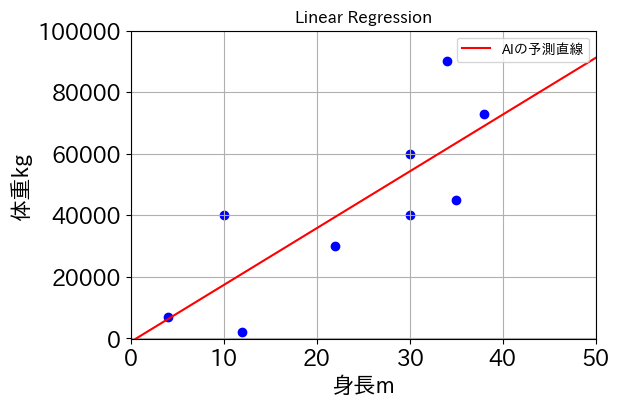

In [38]:
# グラフの描画

X = df[["身長m"]]
y = df["体重kg"]
plt.figure(figsize=[6, 4])
plt.scatter(X, y, color="blue")
plt.title('Linear Regression')
plt.xlabel("身長m", fontsize=16)
plt.ylabel("体重kg", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(0, 50)
plt.ylim(-100, 100000)

slope = 1846.0707
intercept = -1100.5768
plt.axline(xy1=(0, intercept), slope=slope, color="red", label="AIの予測直線")

plt.legend()
plt.grid()
plt.show()